# PPO Training Analysis (IPython)

Run these cells sequentially to inspect training metrics and view each plot inline.

In [5]:
%matplotlib inline
from pathlib import Path
import matplotlib.pyplot as plt
from analyze_training import TrainingAnalyzer

In [6]:
def get_latest_results_dir(base_dir=Path("./results")):
    if not base_dir.exists():
        raise FileNotFoundError(f"Results directory not found: {base_dir}")
    training_dirs = sorted(base_dir.glob("ppo_training_*"))
    if not training_dirs:
        raise FileNotFoundError(f"No training results found in {base_dir}")
    return training_dirs[-1]

def display_plot(plotter, figsize=(8, 4)):
    fig, ax = plt.subplots(figsize=figsize)
    plotter(ax)
    plt.tight_layout()
    plt.show()

In [7]:
results_dir = get_latest_results_dir()
print(f"Using latest training: {results_dir.name}")
analyzer = TrainingAnalyzer(results_dir)

Using latest training: ppo_training_20260208_204554

Training Analyzer Initialized
Results directory: results\ppo_training_20260208_204554
Total episodes: 500
Total updates: 122



In [8]:
analyzer.print_summary()
analyzer.compare_phases()


TRAINING SUMMARY

[Configuration]
  num_elements        : 8
  num_interferers     : 1
  angle_threshold     : 10.0
  penalty_reward      : -10.0
  pd_threshold        : -5.0
  eta_rl              : -15.0
  gamma               : 0.99
  lambda_gae          : 0.95
  clip_range          : 0.3
  learning_rate       : 0.0003
  buffer_size         : 2048
  batch_size          : 128

[Training Statistics]
  Total episodes           : 500
  Total steps              : 250000
  Stored steps             : 250000 (100.0%)
  Skipped steps            : 0 (0.0%)
  Total updates            : 122

[Episode Performance]
  Mean reward (all)        : 9660.45 ± 5252.72
  Mean reward (last 100)   : 15794.03
  Mean SIR (all)           : 19.32 ± 10.51 dB
  Mean SIR (last 100)      : 31.59 dB
  Best episode reward      : 17012.38
  Best episode SIR         : 34.02 dB
  Worst episode SIR        : -0.89 dB

[Update Performance (Stored Transitions)]
  Mean update reward       : 39552.15 ± 21504.90
  Mean update r

In [9]:
plotters = {
    'Episode Rewards': analyzer._plot_episode_rewards,
    'Episode SIRs': analyzer._plot_episode_sirs,
    'Update Rewards': analyzer._plot_update_rewards,
    'Update SIRs': analyzer._plot_update_sirs,
    'Actor Loss': analyzer._plot_actor_loss,
    'Critic Loss': analyzer._plot_critic_loss,
    'KL Divergence': analyzer._plot_kl_divergence,
    'Training Efficiency': analyzer._plot_training_efficiency,
    'Reward Distribution': analyzer._plot_reward_distribution,
    'SIR Distribution': analyzer._plot_sir_distribution,
    'Rolling Statistics': analyzer._plot_rolling_statistics,
    'Learning Progress': analyzer._plot_learning_progress,
}

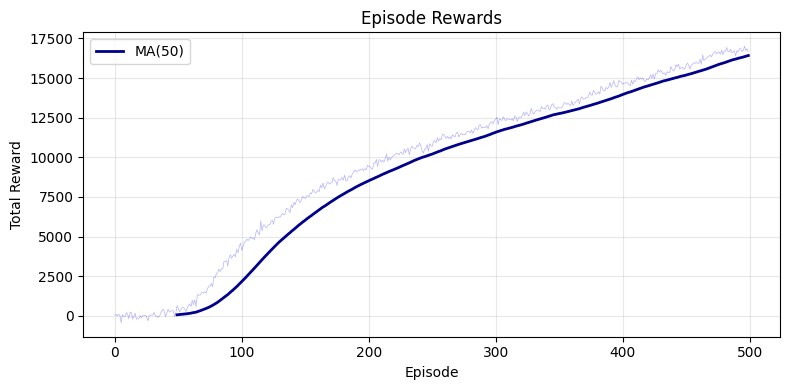

In [10]:
display_plot(plotters['Episode Rewards'])

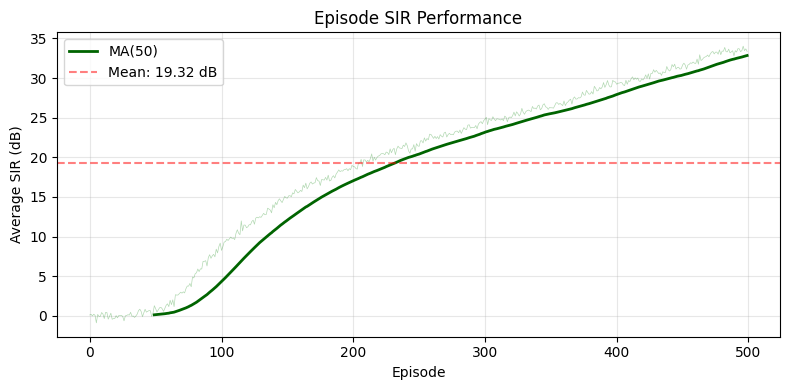

In [11]:
display_plot(plotters['Episode SIRs'])

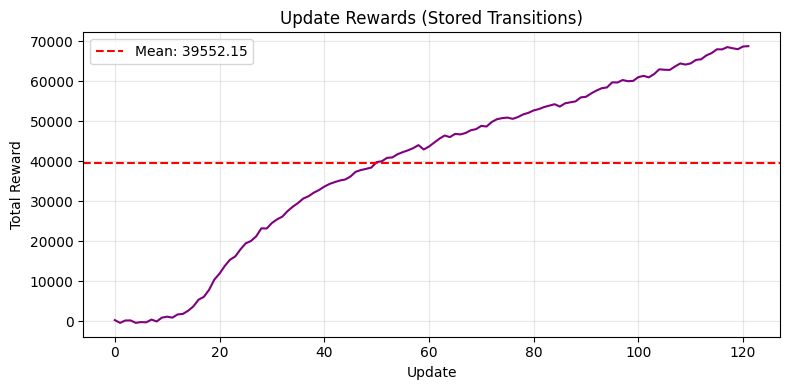

In [12]:
display_plot(plotters['Update Rewards'])

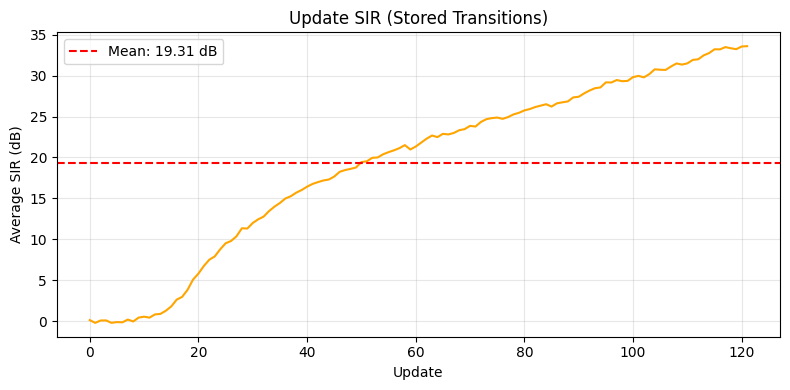

In [13]:
display_plot(plotters['Update SIRs'])

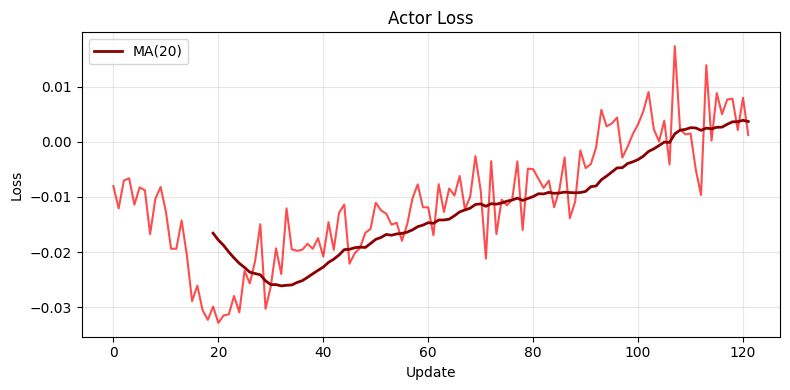

In [14]:
display_plot(plotters['Actor Loss'])

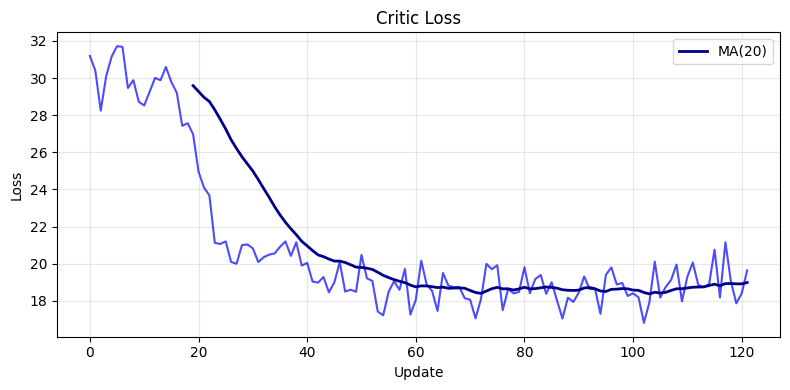

In [23]:
display_plot(plotters['Critic Loss'])

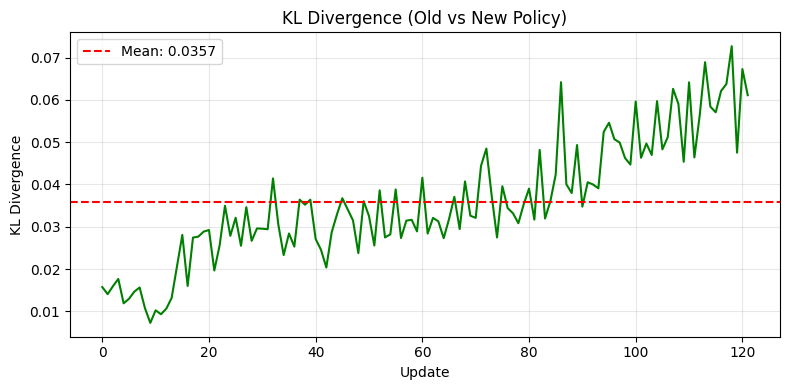

In [16]:
display_plot(plotters['KL Divergence'])

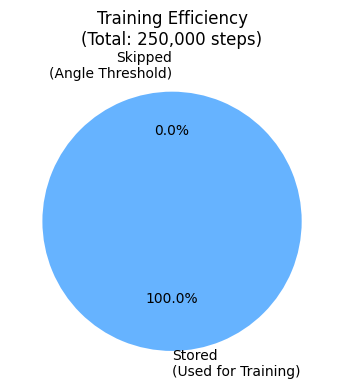

In [17]:
display_plot(plotters['Training Efficiency'])

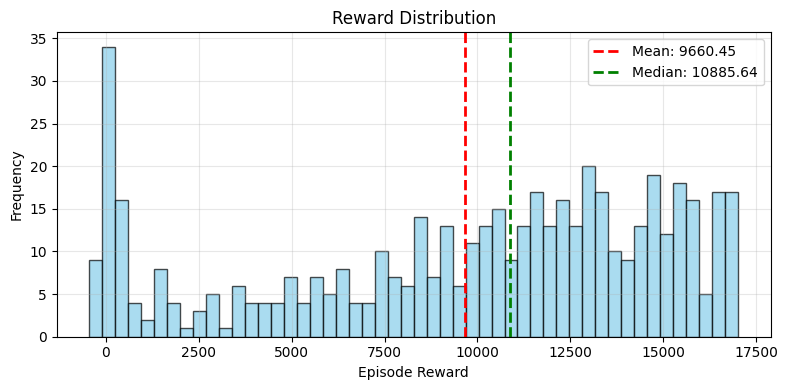

In [18]:
display_plot(plotters['Reward Distribution'])

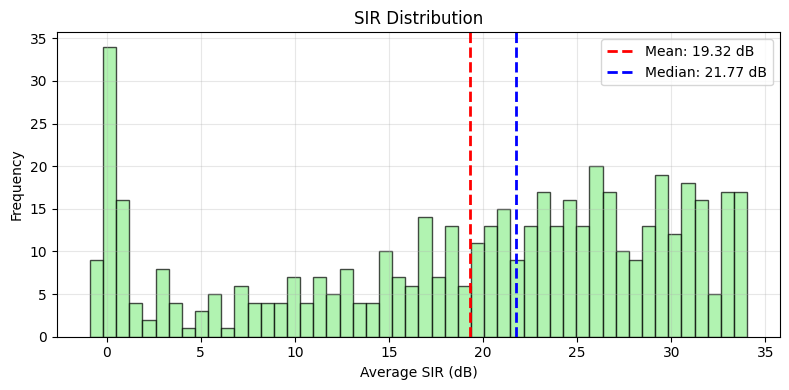

In [19]:
display_plot(plotters['SIR Distribution'])

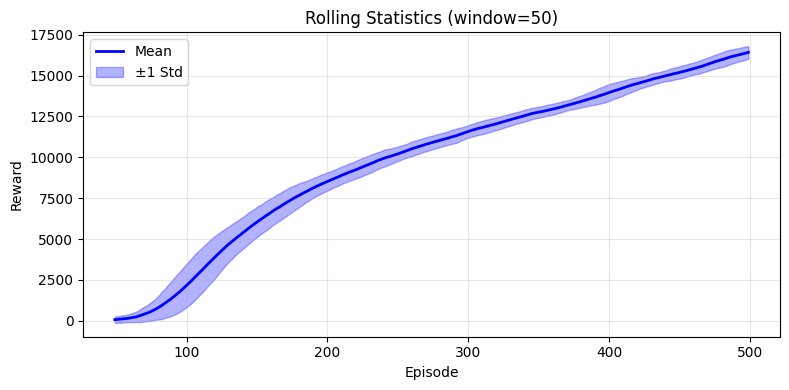

In [20]:
display_plot(plotters['Rolling Statistics'])

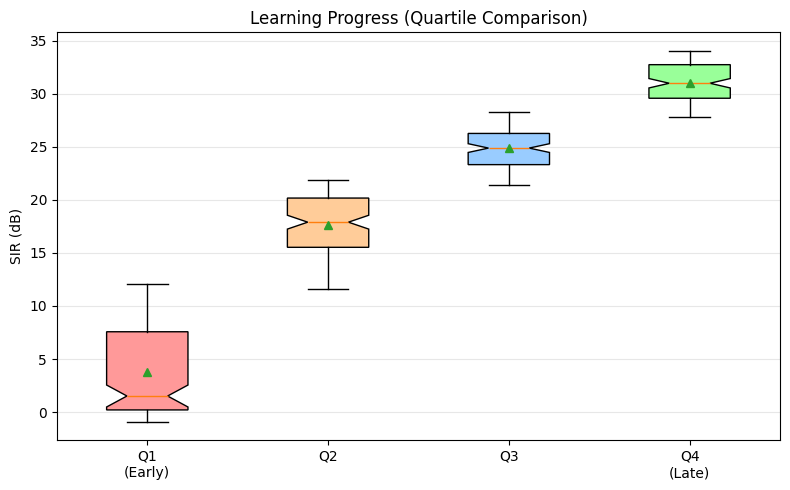

In [21]:
display_plot(plotters['Learning Progress'], figsize=(8, 5))